In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra      
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/speech_emotions.csv
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991b72e0daf97163c09c66/euphoric.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991b72e0daf97163c09c66/joyfully.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991b72e0daf97163c09c66/sad.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991b72e0daf97163c09c66/surprised.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991c3e63d8b20f56d0eeba/euphoric.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991c3e63d8b20f56d0eeba/joyfully.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991c3e63d8b20f56d0eeba/sad.wav
/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991c3e63d8b20f56d0eeba/surprised.wav
/kaggle/i

In [4]:
pip install --upgrade transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 29.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 65.5 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM, AutoModelForMultimodalLM

MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")


# Load model
#音声を扱うためAutoModelForMultimodalLMを使用する
#->これを選択すれば、推論時間が長くなる
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_PATH,
    dtype="auto", #torch_dtype=torch.bfloat16  or dtype="auto"
    device_map="auto" # or "auto" or "None" or "cuda" 
)
   

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

# gemma4に音声(Audio)を入力して、文字おこしさせる　　

**First Task：音声->文字起こし**

**使用データセット**

**https://www.kaggle.com/datasets/tapakah68/emotions-on-audio-dataset**

*Firts Task*

**単純な文字起こし**

In [6]:
from pathlib import Path

def print_tree(path, max_depth=2, prefix=""):
    if max_depth < 0:
        return
    
    for p in sorted(path.iterdir()):
        print(prefix + "├── " + p.name)
        if p.is_dir():
            print_tree(p, max_depth - 1, prefix + "│   ")

root = Path("/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset")

print("=== フォルダ構造（depth=2）===")
print_tree(root, max_depth=2)

=== フォルダ構造（depth=2）===
├── files
│   ├── 00026029e0--64991b6eef1fe70609d48edc
│   │   ├── euphoric.wav
│   │   ├── joyfully.wav
│   │   ├── sad.wav
│   │   ├── surprised.wav
│   ├── 00026029e0--64991b72e0daf97163c09c66
│   │   ├── euphoric.wav
│   │   ├── joyfully.wav
│   │   ├── sad.wav
│   │   ├── surprised.wav
│   ├── 00026029e0--64991b7fd94c0d5726dec353
│   │   ├── euphoric.wav
│   │   ├── joyfully.wav
│   │   ├── sad.wav
│   │   ├── surprised.wav
│   ├── 00026029e0--64991b907f82d9763944eba2
│   │   ├── euphoric.wav
│   │   ├── joyfully.wav
│   │   ├── sad.wav
│   │   ├── surprised.wav
│   ├── 00026029e0--64991bf2ffab6240f9f2418b
│   │   ├── euphoric.mpeg
│   │   ├── joyfully.mpeg
│   │   ├── sad.mpeg
│   │   ├── surprised.mpeg
│   ├── 00026029e0--64991bfc63d8b20f56d0e1fb
│   │   ├── euphoric.wav
│   │   ├── joyfully.wav
│   │   ├── sad.wav
│   │   ├── surprised.wav
│   ├── 00026029e0--64991c0dd94c0d5726df032a
│   │   ├── euphoric.wav
│   │   ├── joyfully.wav
│   │   ├── sad.wav
│ 

In [7]:
import pandas as pd
from pathlib import Path

# CSVのパス
csv_path = Path("/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/speech_emotions.csv")

# 読み込み
df = pd.read_csv(csv_path)

# text列の先頭1つだけ表示
print("=== text列（先頭1行）===")
print(df["text"].iloc[0])

=== text列（先頭1行）===
The delicious aroma of freshly baked bread filled the bakery.


In [8]:
from pathlib import Path

# ルート
root = Path("/kaggle/input/datasets/tapakah68/emotions-on-audio-dataset")

# 対象ファイルのパス
audio_path = root / "files" / "00026029e0--64991b6eef1fe70609d48edc" / "euphoric.wav"

# 変数に格納
audio_1 = audio_path

print("audio_1:", audio_1)

audio_1: /kaggle/input/datasets/tapakah68/emotions-on-audio-dataset/files/00026029e0--64991b6eef1fe70609d48edc/euphoric.wav


**音声再生**

In [9]:
#from IPython.display import Audio

#Audio(audio_1)

**以下のコードでGPUメモリを整理する**

**GPUメモリが不足している時に有効**

In [10]:
import gc

gc.collect()
torch.cuda.empty_cache()

**音声をgemma4に入力する**

In [11]:
import torch
from transformers import GenerationConfig
import time
import librosa


# =========================
# 0. audio_1 がパスの場合は読み込む
# =========================
#
audio_1_wave, sr = librosa.load(audio_1, sr=16000, mono=True) #sr:Hz
audio_1_wave = audio_1_wave.astype("float32")

# =========================
# 1. 文字起こし用プロンプト
# =========================
user_prompt = "Please answer in Japanese. Transcribe this audio.""Transcribe this audio accurately. ""Only output the transcription."

# =========================
# 2. Gemma4 用のマルチモーダル chat 形式
# =========================
messages = [
    {
        "role": "user",
        "content": [
            {"type": "audio", "audio": audio_1_wave},
            {"type": "text", "text": user_prompt},
        ],
    }
]

#これまでは、chat_textとinputsを分けていたが、一緒にすることで成功した。　

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
    
)


# 必要ならGPUへ
if torch.cuda.is_available():
    inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k, v in inputs.items()}

# =========================
# 5. 生成設定
# =========================
gen_config = GenerationConfig(
    max_new_tokens=128,
    do_sample=False,
    temperature=1.0,
)

model.eval()

# =========================
# 6. 推論
# =========================
start_time = time.time()

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        generation_config=gen_config
    )

end_time = time.time()
inference_time = end_time - start_time

# =========================
# 7. デコード
# =========================
generated_text = processor.batch_decode(
    output_ids,
    skip_special_tokens=True,    #特殊トークンを表示しないようにする(Ex.<|audio>)
    clean_up_tokenization_spaces=False,
)[0]

print("=== Prompt ===")
print(user_prompt)
print("\n=== Gemma4 Transcription ===")
print(generated_text)

print("\n=== Inference Time ===")
print(f"{inference_time:.4f} seconds")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Prompt ===
Please answer in Japanese. Transcribe this audio.Transcribe this audio accurately. Only output the transcription.

=== Gemma4 Transcription ===
user
Please answer in Japanese. Transcribe this audio.Transcribe this audio accurately. Only output the transcription.
model
The delicious aroma of freshly baked bread filled the bakery.

=== Inference Time ===
3.4270 seconds


# gemma4に動画を入力して性能を検証する

**First Task**

1. 動画キャプション
2. 物理的な状況の理解をどれだけ理解できているかを検証する

**使用データセット**

**https://physion-benchmark.github.io**

In [13]:
#from pathlib import Path
#import os

#video_dir = Path("/kaggle/input/datasets/itsuki0911/physion/PhysionTrainMP4s/Collide_readout_MP4s")
#mp4_files = sorted(video_dir.glob("*.mp4"))
#original_video = mp4_files[0]
 
#output_path = "/kaggle/working/video_1_7fps.mp4"

#os.system(
    #f'ffmpeg -y -i "{original_video}" -vf "fps=7" -an "{output_path}"'
#)

#video_1 = output_path
#print("video_1:", video_1)

In [22]:
from pathlib import Path

video_dir = Path("/kaggle/input/datasets/itsuki0911/physion-video")

for p in video_dir.rglob("*"):
    print(p)

/kaggle/input/datasets/itsuki0911/physion-video/pilot_it2_collision_assorted_targets_box_1_dis_1_occ_0052_img.mp4


In [43]:
import subprocess
import os

# 実際の動画ファイル
original_video = "/kaggle/input/datasets/itsuki0911/physion-video/pilot_it2_collision_assorted_targets_box_1_dis_1_occ_0052_img.mp4"

# 出力先
output_path = "/kaggle/working/video_1_7fps.mp4"

# ffmpegで7fpsに変換
result = subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-i", original_video,
        "-vf", "fps=7",
        "-an",
        output_path
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

print("returncode:", result.returncode)
print("output exists:", os.path.exists(output_path))

if not os.path.isfile(output_path):
    print(result.stderr)
    raise ValueError("動画変換に失敗しました")

video_1 = output_path
print("video_1:", video_1)

returncode: 0
output exists: True
video_1: /kaggle/working/video_1_7fps.mp4


**動画の再生**

In [44]:
from IPython.display import Video

Video(str(video_1), embed=True, width=600)
#embed:動画ファイルをHTMLの中に“埋め込む（Base64化する）”オプション 
#->実行環境によっては、これがないと再生できない。kaggle notebookではこれがないと再生できない

=== File Check ===
exists: True
isfile: True

=== Video Info ===
FPS: 7.0
Frame count: 35
Resolution: 256 x 256

=== Frame Preview ===


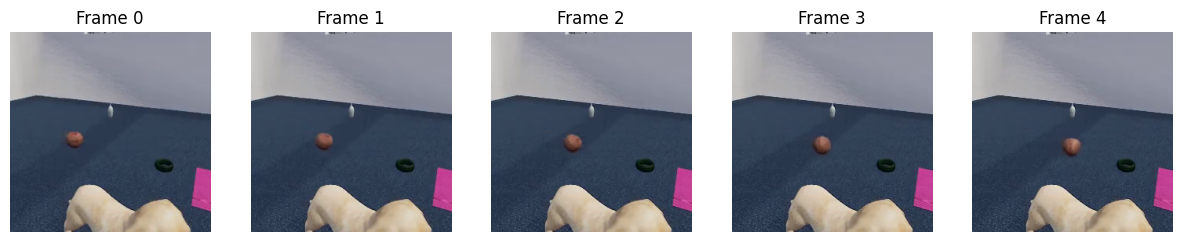

In [45]:
# =========================
# video_1 内容確認（CUDA使わない）
# =========================
import cv2
import os
import matplotlib.pyplot as plt

video_1 = "/kaggle/working/video_1_7fps.mp4"

# =========================
# 1. ファイル存在確認
# =========================
print("=== File Check ===")
print("exists:", os.path.exists(video_1))
print("isfile:", os.path.isfile(video_1))

if not os.path.isfile(video_1):
    raise ValueError("動画ファイルが存在しません")

# =========================
# 2. 動画読み込み
# =========================
cap = cv2.VideoCapture(video_1)

if not cap.isOpened():
    raise ValueError("動画を開けません")

# =========================
# 3. メタ情報取得
# =========================
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("\n=== Video Info ===")
print(f"FPS: {fps}")
print(f"Frame count: {frame_count}")
print(f"Resolution: {width} x {height}")

# =========================
# 4. フレーム取得（最初の数枚）
# =========================
frames = []
num_check_frames = min(5, frame_count)

for i in range(num_check_frames):
    ret, frame = cap.read()
    if not ret:
        print(f"Frame {i} 読み込み失敗")
        break
    frames.append(frame)

cap.release()

# =========================
# 5. フレーム表示
# =========================
print("\n=== Frame Preview ===")

plt.figure(figsize=(15, 3))

for i, frame in enumerate(frames):
    plt.subplot(1, len(frames), i + 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {i}")
    plt.axis("off")

plt.show()

**gemma4に動画を入力する**

In [46]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache() #未使用GPUキャッシュ解放
torch.cuda.ipc_collect() #他のプロセスとの共有用に残っているGPUメモリを解放する

In [47]:
import torch
from transformers import GenerationConfig
import time
# =========================
# 1. 動画説明用プロンプト
# =========================
user_prompt = (
    "Please answer in Japanese. "
    "Describe what is shown in this video. "
    "Also explain the physical situation in the video."  
)

# =========================
# 2. Gemma4 用のマルチモーダル chat 形式
# =========================
messages = [
    {
        "role": "user",
        "content": [
            {"type": "video", "video": video_1},
            {"type": "text", "text": user_prompt},
        ],
    }
]

# =========================
# 3. 入力作成
# =========================
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
    load_audio_from_video=False,
    num_frames=8,
)

# =========================
# 4. 必要ならGPUへ
# =========================
if torch.cuda.is_available():
    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

# =========================
# 5. 生成設定
# =========================
gen_config = GenerationConfig(
    max_new_tokens=256,
    do_sample=False,
    temperature=1.0,
)

model.eval()

# =========================
# 6. 推論
# =========================
start_time = time.time()

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        generation_config=gen_config
    )

end_time = time.time()
inference_time = end_time - start_time

# =========================
# 7. デコード
# =========================
generated_text = processor.batch_decode(
    output_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("=== Prompt ===")
print(user_prompt)

print("\n=== Gemma4 Output ===")
print(generated_text)

print("\n=== Inference Time ===")
print(f"{inference_time:.4f} seconds")

Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


=== Prompt ===
Please answer in Japanese. Describe what is shown in this video. Also explain the physical situation in the video.

=== Gemma4 Output ===
user


00:00  00:00  00:01  00:01  00:02  00:03  00:03  00:04 

Please answer in Japanese. Describe what is shown in this video. Also explain the physical situation in the video.
model
この動画は、3D環境（おそらくゲームやシミュレーション）で撮影された短いクリップです。

**動画の内容の描写:**

* **環境:** 青みがかった床と白い壁がある、シンプルな空間が映っています。
* **オブジェクト:** 床の上には、いくつかのオブジェクトが配置されています。
    * 白い細長い物体（おそらくビー玉や小さなボールのようなもの）が中央付近にあります。
    * 赤茶色の球体（ボール）が中央よりやや右寄りにあります。
    * 緑色の円盤状の物体が赤茶色のボールの近くにあります。
    * 明るいピンク色の板状の物体が右端にあります。
    * 最も目立つのは、画面下部を大きく占めている、茶色っぽい毛皮を持つ動物（犬のように見えます）です。
* **時間経過:** 動画は00:00から00:04まで続いており、オブジェクトの位置や犬の動きに大きな変化は見られませんが、カメラの視点やオブジェクトの相対的な位置関係が確認できます。

**物理的な状況の解説:**

この動画は、物理的な相互作用が起こっている瞬間を捉えている可能性がありますが

=== Inference Time ===
36.0797 seconds
